# App-22 — Sélection empirique d'algorithmes : trois jeux, 13 familles conceptuelles, 14 étiquettes mesurées

[← Search](../../README.md) | [↑ Applications](../README.md) | [<< App-21 VoiceLeading](../CSP/App-21-VoiceLeading.ipynb)

## Hommage à un travail étudiant

Ce notebook distille et replace dans un **cadre plus large** le *Benchmark cross-paradigme de solveurs de jeux* réalisé en solo par **Théodore Deguest** (sujet **L4**, cours *Intelligence Symbolique*, EPITA SCIA) : [PR #42](https://github.com/jsboigeEpita/2026-Epita-Intelligence-Symbolique/pull/42), projet [L4-Benchmark-Cross-Paradigm](https://github.com/jsboigeEpita/2026-Epita-Intelligence-Symbolique/tree/main/L4-Benchmark-Cross-Paradigm).

Son geste intellectuel : faire **courir ensemble** — sur un protocole commun et avec des métriques uniformes — des paradigmes de résolution hétérogènes (recherche exacte, CSP/CP-SAT, SAT/SMT, métaheuristique, recherche adversariale, théorie de l'information) sur trois jeux : **Sudoku**, **Puissance 4** et **Wordle**. Le défi n'est pas d'aligner trois solveurs sur un même problème, mais de comparer ce qui, par construction, **ne se compare pas directement** : un nœud de Dancing Links, une décision CP-SAT, une évaluation de solution génétique et une partie de MCTS ne sont pas la même unité de travail.

Le cadre que ce notebook ajoute : le **problème de sélection d'algorithmes** de **Rice (1976)** et le théorème **No Free Lunch** de **Wolpert & Macready (1997)**, au croisement de trois arcs déjà enseignés dans CoursIA : comparer honnêtement des solveurs ([Sudoku-18/18b](../../../Sudoku/Sudoku-18-Comparison-Python.ipynb)), caractériser puis sélectionner ([MGS-15 → MGS-16](../../Part4-Metaheuristics/MGS-15-LandscapeAnalysis.ipynb)), et décider sous plusieurs attributs ([DecInfer-04](../../../Probas/DecisionTheory/DecInfer/DecInfer-04-Multi-Attribute.ipynb)). Ici, ils deviennent un **cas d'application vivant** : trois terrains, des familles qui ne partagent ni leur représentation, ni leur unité de coût, ni leur définition du succès. La carte complète est donc **instance → représentation → algorithme → configuration/budget → métrique → décision**.

> **Attribution et licence.** Les trois CSV historiques (`{sudoku,connect_four,wordle}_results.csv`) viennent de Théodore Deguest et sont copiés depuis `results/` de sa PR #42, sous **licence MIT** (copyright 2026, « The 2026-Epita-Intelligence-Symbolique contributors »). Le quatrième CSV (`wordle_repeated_results.csv`) est une **dérivation CoursIA** obtenue en rejouant son code inchangé selon le protocole documenté dans `SOURCE.md`. Toute l'analyse de ce notebook est nouvelle. Aucun solveur étudiant n'est recopié : ils restent dans le dépôt source, référencé et testé.

## Objectifs

1. **Reconnaître** un appareil de mesure expérimental étudiant (protocole commun, métriques uniformes, timeouts, checkpoints).
2. **Établir** la provenance et le schéma des données avant toute analyse.
3. **Démontrer** que `nodes_explored`, `time_seconds` et `solution_quality` ne sont **pas commensurables** entre familles.
4. **Quantifier** la dispersion inter-instance et multi-seed, sans confondre ces deux sources d'incertitude.
5. **Calculer** des profils et des **frontières de Pareto** intra-jeu, sans podium global fallacieux.
6. **Relier** la sélection de solveur au cadre de **Rice** et à la décision multi-attribut, puis tester la sensibilité aux préférences.
7. **Séparer** performance empirique et garantie formelle grâce à des ponts Lean ciblés.

## Prérequis

- [Sudoku-18b](../../../Sudoku/Sudoku-18b-Statistical-Comparison-Python.ipynb) (comparaison statistique honnête).
- [MGS-15](../../Part4-Metaheuristics/MGS-15-LandscapeAnalysis.ipynb) puis [MGS-16](../../Part4-Metaheuristics/MGS-16-AlgorithmSelection.ipynb) (caractérisation, sélection, No Free Lunch).
- [DecInfer-04](../../../Probas/DecisionTheory/DecInfer/DecInfer-04-Multi-Attribute.ipynb) (décision multicritère et sensibilité des poids).
- `pandas`, `numpy`, `matplotlib` (déjà présents dans `Search/requirements.txt`).

## Durée

~45 min. Le notebook ne régénère **aucun** benchmark : il ré-analyse des résultats précalculés (**offline**, aucun appel API, aucun réseau, aucun GPU).

## 1. Transmission : ce qui vient de l'étudiant, ce qui vient de CoursIA

L'hommage ne consiste pas à recopier le travail, mais à **le faire briller en l'associant à un cadre plus grand**. Pour cela, distinguer explicitement l'origine de chaque brique.

| Brique | Origine | Ce qui est fourni ici |
|---|---|---|
| **Solveurs** (backtracking±MRV, Dancing Links, CP-SAT, SMT, GA, recuit simulé ; minimax, alpha-beta, MCTS, baseline ; élimination bayésienne, entropie, CSP) | **Théodore Deguest** | Référencés et testés, **non recopiés** ; liens vers le dépôt source |
| **Protocole expérimental** (instances, timeouts 120 s, parallélisation, métriques) | Théodore Deguest | Récapitulé, non modifié |
| **Données historiques** (`results/*.csv`) | Théodore Deguest | Trois CSV copiés dans `data/app22-cross-paradigm/` sous licence MIT |
| **Données répétées Wordle** | Code et instances de Théodore ; protocole/collecte **CoursIA** | 45 observations dérivées, provenance séparée dans `SOURCE.md` |
| **Analyse** (profils, Pareto, sélection sous préférences, limites) | **CoursIA** | Nouvelle, ce notebook |
| **Cadre** (Rice 1976, No Free Lunch) | CoursIA | Rappel de [MGS-16](../../Part4-Metaheuristics/MGS-16-AlgorithmSelection.ipynb), appliqué ici |

**Traçabilité de l'hommage.** La citation exacte à retenir : *« Benchmark cross-paradigme de solveurs de jeux »*, Théodore Deguest, sujet L4, cours Intelligence Symbolique EPITA SCIA, PR #42. Le dépôt source est sous licence MIT collective : la ré-analyse et la redistribution des **données** sont permises, à condition de conserver le copyright et la mention de licence (voir `data/app22-cross-paradigm/`) — la **ré-écriture d'analyse** en est une ré-utilisation légitime.

### Ce qui existait déjà — et ce que Théodore déplace

CoursIA possède déjà un benchmark multi-solveurs sur un terrain : [Sudoku-18](../../../Sudoku/Sudoku-18-Comparison-Python.ipynb) compare plusieurs philosophies derrière une grille commune, et [Sudoku-18b](../../../Sudoku/Sudoku-18b-Statistical-Comparison-Python.ipynb) montre pourquoi moyenne, variance, intervalle bootstrap et tests appariés doivent rester ensemble. **L'apport de Théodore n'est donc pas « comparer des solveurs Sudoku »**. Il généralise ce geste à **trois terrains** et fait apparaître une difficulté nouvelle : les familles changent aussi la **représentation** et le sens des métriques.

Cette extension rejoint [MGS-21-Représentation-vs-Algorithme](../../Part4-Metaheuristics/MGS-21-Representation-vs-Algorithme.ipynb) : choisir DLX, CP-SAT, SMT, MCTS ou entropie, ce n'est pas seulement changer d'algorithme, c'est changer l'objet sur lequel on raisonne. Le benchmark étudiant devient ainsi le chaînon concret entre **comparaison empirique** (Sudoku-18/18b), **caractérisation et sélection** (MGS-15/16) et **effet de la représentation** (MGS-21).


## 2. Le contrat expérimental étudiant

Avant de raisonner, **charger les données et vérifier leur contrat**. Le notebook est exécuté avec `cwd = dossier du notebook` (convention `scripts/notebook_tools`), mais l'ancrage ci-dessous tolère un cwd différent en remontant vers un dossier contenant `data/app22-cross-paradigm/`.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ancrage des données (robuste au cwd d'exécution)
def data_dir():
    here = Path.cwd()
    for base in (here, here.parent, here.parent.parent):
        cand = base / "data" / "app22-cross-paradigm"
        if (cand / "sudoku_results.csv").exists():
            return cand
    return here / "data" / "app22-cross-paradigm"

DATA = data_dir()

def load_results(game):
    return pd.read_csv(DATA / f"{game}_results.csv")

games = ["sudoku", "connect_four", "wordle"]
frames = {g: load_results(g) for g in games}

print("Répertoire de données : data/app22-cross-paradigm")
print()
for g in games:
    df = frames[g]
    print(f"{g:14s} {len(df):4d} lignes  |  {len(df.columns)} colonnes  |  {df['paradigm'].nunique()} familles  |  {df['instance_id'].nunique()} instances")
print()
print("--- Contrats de schéma (colonnes communes / spécifiques) ---")
commun = set(frames[games[0]].columns)
for g in games[1:]:
    commun &= set(frames[g].columns)
print("Colonnes communes aux trois :", ", ".join(sorted(commun)))
for g in games:
    spec = [c for c in frames[g].columns if c not in commun]
    print(f"  {g} : spécifiques -> {spec if spec else '(aucune)'}")

Répertoire de données : data/app22-cross-paradigm

sudoku          210 lignes  |  10 colonnes  |  7 familles  |  30 instances
connect_four     35 lignes  |  10 colonnes  |  4 familles  |  10 instances
wordle          120 lignes  |  9 colonnes  |  3 familles  |  40 instances

--- Contrats de schéma (colonnes communes / spécifiques) ---
Colonnes communes aux trois : difficulty, game, instance_id, nodes_explored, paradigm, peak_memory_mb, solution_quality, success, time_seconds
  sudoku : spécifiques -> ['extra_budget_exceeded']
  connect_four : spécifiques -> ['extra_winner']
  wordle : spécifiques -> (aucune)


Le tableau ci-dessus matérialise déjà une première limite : les trois fichiers partagent un **noyau commun** (`game, paradigm, instance_id, difficulty, success, time_seconds, peak_memory_mb, nodes_explored, solution_quality`) mais chacun ajoute **une colonne spécifique** (`extra_budget_exceeded` pour Sudoku, `extra_winner` pour Puissance 4). Le schéma est **uniforme par intention, hétérogène par détail** — la comparabilité doit donc se construire, pas se supposer.

**Un mot sur le décompte.** Le README étudiant annonce **13 solveurs/familles** (6 Sudoku — backtracking et MRV groupés —, 4 Puissance 4 dont le baseline, 3 Wordle). Les CSV portent **14 étiquettes de paradigme** distinctes, car `backtracking` et `backtracking_mrv` sont deux lignes séparées. Ce petit écart compte : il illustre qu'un « solveur » peut être décrit à deux grains, et que la **définition** de la population fait partie du contrat expérimental.

On vérifie maintenant la répartition des familles et des difficultés, pour ne pas comparer des populations différentes.

In [2]:
for g in games:
    df = frames[g]
    print(f"===== {g} : familles et difficultés =====")
    for fam, grp in df.groupby("paradigm"):
        diffs = grp["difficulty"].unique()
        print(f"  {fam:24s} n={len(grp):3d}  difficultés={sorted(map(str, diffs))}")
    print()

===== sudoku : familles et difficultés =====
  backtracking             n= 30  difficultés=['diabolical', 'easy', 'medium_hard']
  backtracking_mrv         n= 30  difficultés=['diabolical', 'easy', 'medium_hard']
  cp_sat                   n= 30  difficultés=['diabolical', 'easy', 'medium_hard']
  dancing_links            n= 30  difficultés=['diabolical', 'easy', 'medium_hard']
  genetic                  n= 30  difficultés=['diabolical', 'easy', 'medium_hard']
  simulated_annealing      n= 30  difficultés=['diabolical', 'easy', 'medium_hard']
  smt                      n= 30  difficultés=['diabolical', 'easy', 'medium_hard']

===== connect_four : familles et difficultés =====
  alpha_beta               n=  9  difficultés=['1', '2', '3', '4', '5', '6', '7', '8', '9']
  baseline                 n= 10  difficultés=['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']
  mcts                     n= 10  difficultés=['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']
  minimax                  

## 2 bis. Une moyenne n'est pas une preuve : deux niveaux d'incertitude

[Sudoku-18b](../../../Sudoku/Sudoku-18b-Statistical-Comparison-Python.ipynb) distingue le bruit du système, la variance entre puzzles, l'intervalle bootstrap et les tests appariés. Appliquons cette discipline aux données de Théodore.

### 2 bis-A — Incertitude inter-instance dans les CSV historiques

Les CSV contiennent une mesure par couple `paradigm × instance_id`, mais les **mêmes instances** sont bien partagées : 30 pour tous les solveurs Sudoku, 40 pour Wordle, et au moins 6 pour Puissance 4 (les solveurs profonds s'arrêtent plus tôt). Nous pouvons donc bootstrapper les **instances** pour quantifier l'incertitude sur ce panel. Cet intervalle ne mesure pas le bruit runtime d'une même instance et ne crée pas artificiellement des répétitions.


In [3]:
def bootstrap_ci(values, stat=np.mean, n_boot=4000, seed=2026):
    # Intervalle percentile déterministe sur l'échantillon d'instances.
    x = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    boots = [stat(rng.choice(x, size=len(x), replace=True)) for _ in range(n_boot)]
    return float(stat(x)), float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

print("Couverture et IC bootstrap 95 % inter-instance (médiane du temps, taux de succès) :")
for game in games:
    print(f"\n===== {game} =====")
    df = frames[game]
    common = set.intersection(*(
        set(grp["instance_id"].astype(str)) for _, grp in df.groupby("paradigm")
    ))
    print(f"instances communes à toutes les familles : {len(common)}")
    for paradigm, grp in df.groupby("paradigm"):
        med, lo_t, hi_t = bootstrap_ci(grp["time_seconds"], stat=np.median)
        suc, lo_s, hi_s = bootstrap_ci(grp["success"].astype(float), stat=np.mean)
        print(f"  {paradigm:24s} n={len(grp):2d} | succès={suc:.2f} [{lo_s:.2f}; {hi_s:.2f}]"
              f" | temps médian={med:.4g} [{lo_t:.4g}; {hi_t:.4g}]")

Couverture et IC bootstrap 95 % inter-instance (médiane du temps, taux de succès) :

===== sudoku =====
instances communes à toutes les familles : 30
  backtracking             n=30 | succès=0.73 [0.57; 0.87] | temps médian=0.4482 [0.04185; 0.7099]


  backtracking_mrv         n=30 | succès=1.00 [1.00; 1.00] | temps médian=0.04201 [0.01914; 0.1235]


  cp_sat                   n=30 | succès=1.00 [1.00; 1.00] | temps médian=0.01087 [0.007851; 0.01245]
  dancing_links            n=30 | succès=1.00 [1.00; 1.00] | temps médian=0.004011 [0.002648; 0.008744]


  genetic                  n=30 | succès=0.00 [0.00; 0.00] | temps médian=9.403 [8.917; 10.07]


  simulated_annealing      n=30 | succès=0.20 [0.07; 0.33] | temps médian=2.596 [2.495; 2.697]
  smt                      n=30 | succès=1.00 [1.00; 1.00] | temps médian=0.2544 [0.163; 0.3739]

===== connect_four =====
instances communes à toutes les familles : 6


  alpha_beta               n= 9 | succès=0.67 [0.33; 1.00] | temps médian=1.268 [0.5016; 10.51]


  baseline                 n=10 | succès=0.00 [0.00; 0.00] | temps médian=0.3433 [0.2907; 0.3699]
  mcts                     n=10 | succès=0.00 [0.00; 0.00] | temps médian=1.8 [1.25; 2.2]


  minimax                  n= 6 | succès=0.67 [0.33; 1.00] | temps médian=1.491 [0.4461; 35.16]

===== wordle =====
instances communes à toutes les familles : 40


  bayesian_elimination     n=40 | succès=1.00 [1.00; 1.00] | temps médian=0.003177 [0.002933; 0.003338]
  csp                      n=40 | succès=1.00 [1.00; 1.00] | temps médian=0.1099 [0.102; 0.1184]


  entropy                  n=40 | succès=1.00 [1.00; 1.00] | temps médian=6.865 [6.545; 7.527]


**Lecture honnête.** Les intervalles se resserrent quand les résultats sont homogènes et s'élargissent quand les instances discriminent davantage. Sur Puissance 4, les effectifs inégaux rendent la comparaison plus fragile : un test apparié à quatre familles devrait se limiter aux **6 instances communes**, et ne répondrait qu'à ce sous-panel. Nous n'en fabriquons pas ici un verdict universel.

### 2 bis-B — Répétition fraîche multi-seed sur Wordle

Pour compléter les CSV historiques, CoursIA a rejoué le **code étudiant inchangé** sous WSL/Linux le 24 août 2026 : 3 instances de longueur 5 (`sample_instances(..., seed=42)`), 3 solveurs, 5 graines, soit **45 mesures**. Le cache du premier coup entropique a été vidé avant chaque mesure : sans cela, un run froid suivi de runs chauds aurait produit une fausse accélération. Le protocole exact et la provenance sont consignés dans `data/app22-cross-paradigm/SOURCE.md`.

Cette petite expérience mesure deux choses distinctes : la variabilité **entre graines** pour les solveurs qui utilisent un RNG, et la variabilité **entre instances**. Elle n'est pas un nouveau benchmark exhaustif et ne remplace pas les 120 lignes historiques.


In [4]:
repeated = pd.read_csv(DATA / "wordle_repeated_results.csv")
assert len(repeated) == 45
assert repeated.groupby(["paradigm", "instance_id"]).size().eq(5).all()

# Bootstrap hiérarchique : ré-échantillonner les instances, puis les graines en leur sein.
def hierarchical_ci(df, value, n_boot=4000, seed=2026):
    rng = np.random.default_rng(seed)
    ids = df["instance_id"].unique()
    observed = float(df[value].mean())
    draws = []
    for _ in range(n_boot):
        sampled_ids = rng.choice(ids, size=len(ids), replace=True)
        vals = []
        for instance_id in sampled_ids:
            pool = df.loc[df["instance_id"] == instance_id, value].to_numpy(float)
            vals.extend(rng.choice(pool, size=len(pool), replace=True))
        draws.append(np.mean(vals))
    return observed, float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))

print("Wordle frais — 3 instances × 5 graines par solveur (IC hiérarchique 95 %) :")
for paradigm, grp in repeated.groupby("paradigm"):
    q, lo_q, hi_q = hierarchical_ci(grp, "solution_quality")
    per_instance_sd = grp.groupby("instance_id")["solution_quality"].std()
    print(f"  {paradigm:24s} succès={grp['success'].mean():.2f} | coups={q:.2f} [{lo_q:.2f}; {hi_q:.2f}]"
          f" | écart-type inter-seed médian={per_instance_sd.median():.2f}")

print("\nContrôle déterminisme par instance (nombre de qualités distinctes sur 5 graines) :")
print(repeated.groupby(["paradigm", "instance_id"])["solution_quality"].nunique().unstack().to_string())

Wordle frais — 3 instances × 5 graines par solveur (IC hiérarchique 95 %) :


  bayesian_elimination     succès=1.00 | coups=3.67 [3.27; 4.13] | écart-type inter-seed médian=0.71


  csp                      succès=1.00 | coups=4.20 [3.60; 4.87] | écart-type inter-seed médian=0.55


  entropy                  succès=1.00 | coups=3.33 [3.00; 4.00] | écart-type inter-seed médian=0.00

Contrôle déterminisme par instance (nombre de qualités distinctes sur 5 graines) :
instance_id           len5_0  len5_1  len5_2
paradigm                                    
bayesian_elimination       2       3       3
csp                        2       3       2
entropy                    1       1       1


**Résultat reproductible, limite conservée.** Les 45 runs réussissent. L'entropie est déterministe à instance fixée (une qualité distincte pour chaque instance) ; l'élimination bayésienne et le CSP varient avec la graine. Avec seulement trois mots, les intervalles restent volontairement larges : ils démontrent la **dispersion**, pas une supériorité générale. Une étude confirmatoire devrait augmenter le nombre d'instances, isoler chaque processus, multiplier les machines ou répéter les temps après warm-up selon la question posée.


## 3. `nodes_explored` : la même colonne, des unités différentes

Le piège le plus visible est la colonne `nodes_explored` : même nom, même type numérique… et **aucune commune mesure**. Un « nœud » n'est pas un nœud selon la famille :

- **Backtracking / MRV** et **Dancing Links** : un *nœud d'arbre de recherche* (case affectée / étape de couverture exacte). Comparables *entre eux*.
- **CP-SAT** : le solveur travaille par **propagation de contraintes et analyse de conflits** — les « nœuds » qu'il rapporte sont une **unité interne au solveur** (≈55 en moyenne ici), **pas** une énumération d'affectations. Cette valeur ne se compare à aucun nœud d'arbre.
- **SMT** : un *nombre de décisions* dans la procédure de décision.
- **GA / recuit simulé** : une *évaluation de fonction-objectif* (individu / état visité).
- **MCTS** : une *simulation de partie complète*.
- **Mot** (Wordle, élimination bayésienne / entropie) : un *candidat évalué* ; **CSP** (Wordle) : **`0`** (résolution par satisfaisabilité de contraintes, pas d'énumération).

On juxtapose la colonne brute, puis on s'interdit de la classer globalement.

In [5]:
sud = frames["sudoku"]
nodes_pivot = sud.pivot_table(index="paradigm", values="nodes_explored", aggfunc="mean") \
                  .sort_values("nodes_explored")
nodes_pivot.columns = ["nodes_explored (moy.)"]
print("Sudoku — `nodes_explored` moyen par famille :")
print(nodes_pivot.round(1).to_string())
print()
print("Lecture : le CP-SAT rapporte ~55 'nœuds' internes (propagation/conflits),")
print("le Wordle-CSP en rapporte 0, le backtracking ~804k d'énumération d'affectations,")
print("le GA ~400k d'évaluations. Aucune de ces valeurs ne compte le même travail.")
print("La colonne ne mesure PAS le même travail d'une famille à l'autre.")

Sudoku — `nodes_explored` moyen par famille :
                     nodes_explored (moy.)
paradigm                                  
cp_sat                                55.5
dancing_links                        217.3
smt                                 5936.9
backtracking_mrv                   91682.1
simulated_annealing               248836.0
genetic                           400200.0
backtracking                      804024.9

Lecture : le CP-SAT rapporte ~55 'nœuds' internes (propagation/conflits),
le Wordle-CSP en rapporte 0, le backtracking ~804k d'énumération d'affectations,
le GA ~400k d'évaluations. Aucune de ces valeurs ne compte le même travail.
La colonne ne mesure PAS le même travail d'une famille à l'autre.


**Conséquence immédiate** : il est **mathématiquement invalide** de trier les 14 étiquettes de paradigme sur `nodes_explored`, ou de conclure « le solveur qui explore le moins est le meilleur ». Le notebook de l'étudiant le souligne déjà ; nous le formalisons ici comme un cas d'école du problème de **Rice** : les **attributs** d'une instance ne sont pas homogènes entre **espaces d'algorithmes**.

La **même** prudence vaut pour `time_seconds` (un solveur en pur Python vs un binding C++ natif) et pour `solution_quality` (voir §4). Toute normalisation doit donc être **intra-jeu** — jamais inter-jeu, jamais inter-famille de manière naïve.


## 4. Profils intra-jeu : succès, coût relatif, qualité, répétitions

On agrège par famille **dans chaque jeu**, pour faire apparaître ce que chaque paradigme optimise réellement. Les durées absolues dépendent de la machine d'exécution du benchmark (état Unix) ; on parle donc surtout en **ratios** (`rel_time`, `rel_mem` : 1 = meilleur de son jeu) et en **taux**, jamais en secondes dans la prose.


In [6]:
def profile(df, quality_dir=None):
    g = df.groupby("paradigm")
    p = pd.DataFrame({
        "instances": df.groupby("paradigm")["instance_id"].nunique(),
        "n": df.groupby("paradigm")["instance_id"].count(),
        "success_rate": df.groupby("paradigm")["success"].mean(),
        "mean_time": df.groupby("paradigm")["time_seconds"].mean(),
        "mean_mem": df.groupby("paradigm")["peak_memory_mb"].mean(),
        "mean_nodes": df.groupby("paradigm")["nodes_explored"].mean(),
    })
    if "solution_quality" in df.columns:
        p["mean_quality"] = df.groupby("paradigm")["solution_quality"].mean()
    p = p.reset_index()
    t_min = p["mean_time"].min(); m_min = p["mean_mem"].min()
    p["rel_time"] = (t_min / p["mean_time"]).replace([np.inf], np.nan)
    p["rel_mem"] = (m_min / p["mean_mem"]).replace([np.inf], np.nan)
    return p

profiles = {}
for g in games:
    profiles[g] = profile(frames[g])
    print(f"===== {g} =====")
    cols = [c for c in ["paradigm","instances","success_rate","mean_time","mean_mem",
                        "mean_nodes","mean_quality","rel_time","rel_mem"] if c in profiles[g].columns]
    print(profiles[g][cols].round(3).to_string(index=False))
    print()

===== sudoku =====
           paradigm  instances  success_rate  mean_time  mean_mem  mean_nodes  mean_quality  rel_time  rel_mem
       backtracking         30         0.733      0.522    56.556  804024.867           NaN     0.011    1.000
   backtracking_mrv         30         1.000      1.236    56.739   91682.100           NaN     0.005    0.997
             cp_sat         30         1.000      0.010    74.145      55.467           NaN     0.558    0.763
      dancing_links         30         1.000      0.006    58.002     217.333           NaN     1.000    0.975
            genetic         30         0.000      9.410    57.918  400200.000         5.933     0.001    0.976
simulated_annealing         30         0.200      2.198    57.179  248836.000         2.267     0.003    0.989
                smt         30         1.000      0.328    92.238    5936.867           NaN     0.018    0.613

===== connect_four =====
  paradigm  instances  success_rate  mean_time  mean_mem  mean_node

**Ce que ces profils révèlent.**

- **Sudoku** — les familles **exactes** (Dancing Links, CP-SAT, SMT, backtracking-MRV) réussissent à 100 % ; les **métaheuristiques** (GA, recuit simulé) **échouent** massivement (succès 0 / 0.2). Sur Sudoku, la recherche **heuristique** n'est pas une alternative à la résolution exacte : c'est un **mauvais outil**. La colonne `solution_quality` est ici **singulière** : les solveurs **exacts** ne la renseignent pas (succès dichotomique), seules les métaheuristiques qui **échouent** renseignent une **fitness partielle** (`best_fitness`/`best_cost` selon le solveur, ≈5.9 pour le GA, ≈2.3 pour le recuit simulé). C'est une *fitness partielle* d'échec, **pas une qualité de solution** : la traiter comme un objectif à maximiser récompenserait les pires solveurs — on l'exclut donc de la sélection (§6).
- **Puissance 4** — `minimax` et `alpha-beta` réussissent ~67 % ; **MCTS** et **baseline** échouent (0 %). La colonne `mean_quality` (évaluation heuristique de la position gagnante) est ici **plus haute = meilleure** : le tableau montre le **compromis** entre minimax et alpha-beta (qualité vs temps), sans qu'un podium unique soit honnête.
- **Wordle** — les **trois** familles réussissent à 100 % ; la discrimine **la qualité** (`mean_quality` = *nombre de coups*, **plus bas = meilleur**) : l'entropie (≈2.7 coups) bat l'élimination bayésienne (≈3.3) et le CSP (≈3.4).

**Direction de la qualité non uniforme** : meilleure = basse (Wordle, nb de coups), meilleure = haute (Puissance 4, évaluation), absente (Sudoku). Encore une **non-commensurabilité**.

### Exercice 1 (stub) — ajouter une métrique normalisée
L'exemple ci-dessus normalise coût et mémoire *relativement au meilleur du jeu*. À vous d'ajouter un **indicateur de rendement composé** (par ex. *instances réussies par unité de temps et de mémoire*), qui agrège succès, temps et mémoire en une seule valeur **par jeu**.


In [7]:
# INDICE :
#  - success_rate  = proportion d'instances réussies  (0..1, mieux = haut)
#  - rel_time      = temps relatif au meilleur        (0..1 = meilleur, bas = rapide -> 1 = rapide)
#  - rel_mem       = mémoire relative au meilleur     (idem, bas = 1 = léger)
#  - une métrique "rendement" combine les trois de façon *croissante*.
def add_throughput(df):
    # Ajoute une colonne `throughput` = rendement composé succès/temps/mémoire
    # (compose les indicateurs déjà normalisés : plus haut = meilleur).
    out = df.copy()
    # ÉTAPE 1 : vérifier la présence des colonnes normalisées (sinon les calculer)
    # ÉTAPE 2 : combiner success_rate, rel_time, rel_mem en une seule valeur
    # ÉTAPE 3 : renommer la nouvelle colonne
    result = None
    return result  # TODO : compléter (voir indices ci-dessus)

# --- Test simple : si l'implémentation est complétée, affiche le rendement par jeu ---
# for g in games:
#     p = add_throughput(profiles[g])
#     print(g, p[["paradigm","throughput"]].round(3).sort_values("throughput", ascending=False).to_string(index=False))
print("Exercice 1 (stub) — à compléter pour dériver un rendement composé par jeu.")

Exercice 1 (stub) — à compléter pour dériver un rendement composé par jeu.


## 5. Frontières de Pareto : un podium unique efface les compromis

Un « classement » qui somme des métriques non commensurables produit un gagnant **fictif** : il suppose un taux d'échange entre unités qui n'a pas de sens. La **dominance de Pareto** est plus honnête : un solveur est non dominé si aucun autre ne fait **strictement mieux sur toute la ligne** (même succès, coût moindre ; même coût, succès meilleur, etc.). Le **front non dominé** est l'ensemble des **compromis** légitimes.

C'est le même rôle que la frontière efficiente dans [App-10-Portfolio](App-10-Portfolio.ipynb) : elle élimine les alternatives dominées, mais ne choisit pas le compromis risque–rendement à la place de l'investisseur. Ici, elle ne choisit pas le compromis succès–temps–mémoire–qualité à la place de l'utilisateur du solveur.

On l'applique avec deux objectifs **par jeu**, choisis pour être parlants (le choix des objectifs eux-mêmes fait partie du cadre : il n'y a pas d'objectifs « naturels »).


In [8]:
def non_dominated(df, obj_spec):
    # df : lignes = alternatives, colonnes = objectifs.
    # obj_spec : [(col, 'max'|'min'), ...]. Retourne les lignes NON dominées.
    from itertools import product
    pts = df[[c for c, _ in obj_spec]].to_numpy(float)
    n = len(pts)
    dominated = set()
    def better(a, b):
        atleast, strict = True, False
        for j, (c, d) in enumerate(obj_spec):
            if d == 'max':
                if a[j] < b[j]: atleast = False
                if a[j] > b[j]: strict = True
            else:
                if a[j] > b[j]: atleast = False
                if a[j] < b[j]: strict = True
        return atleast and strict
    for i in range(n):
        for k in range(n):
            if i != k and better(pts[i], pts[k]):
                dominated.add(k)
    return df.iloc[[i for i in range(n) if i not in dominated]]

# Sudoku & Puissance 4 : (max succès, min temps)
for g in ["sudoku", "connect_four"]:
    pr = profiles[g]
    front = non_dominated(pr, [("success_rate", "max"), ("mean_time", "min")])
    print(f"===== {g} : front non dominé (max succès, min temps) =====")
    print(front[["paradigm", "success_rate", "mean_time"]].round(3).to_string(index=False))
    print("  Paradigmes dominés :", sorted(set(pr["paradigm"]) - set(front["paradigm"])))
    print()

# Wordle : TOUS réussissent -> discriminer sur (min temps, min qualité)
pr = profiles["wordle"]
front = non_dominated(pr, [("mean_time", "min"), ("mean_quality", "min")])
print("===== wordle : front non dominé (min temps, min qualité=guesses) =====")
print(front[["paradigm", "mean_time", "mean_quality"]].round(3).to_string(index=False))
print("  Paradigmes dominés :", sorted(set(pr["paradigm"]) - set(front["paradigm"])))

===== sudoku : front non dominé (max succès, min temps) =====
     paradigm  success_rate  mean_time
dancing_links           1.0      0.006
  Paradigmes dominés : ['backtracking', 'backtracking_mrv', 'cp_sat', 'genetic', 'simulated_annealing', 'smt']

===== connect_four : front non dominé (max succès, min temps) =====
  paradigm  success_rate  mean_time
alpha_beta         0.667     10.463
  baseline         0.000      0.332
  Paradigmes dominés : ['mcts', 'minimax']

===== wordle : front non dominé (min temps, min qualité=guesses) =====
            paradigm  mean_time  mean_quality
bayesian_elimination      0.003         3.300
             entropy      6.493         2.725
  Paradigmes dominés : ['csp']


**Question de méthode.** Remarquez que le front **dépend du couple d'objectifs** choisi. Sur Wordle, si on ne retient que *min temps*, **n'importe quel** choix d'objectif est un choix arbitraire : c'est une décision de modélisation, pas un fait de la nature. C'est exactement le point de **Rice** : le sélectionneur doit choisir **quels attributs** il optimise avant de choisir un algorithme.

Vous le constaterez dans le tableau : sur **Sudoku**, le front `(max succès, min temps)` se réduit à **un seul point** — Dancing Links domine si nettement qu'aucun compromis n'apparaît ; sur **Wordle**, le front oppose *rapidité* (bayésien) à *qualité* (entropie), et le **CSP** est dominé. Le front n'est pas un podium : il dit ce qui **reste possible**, pas ce qui gagne. Il reste muet tant qu'on n'a pas choisi de préférences — c'est l'objet de la section suivante.

Visualisons la frontière sur Sudoku pour la rendre tangible.

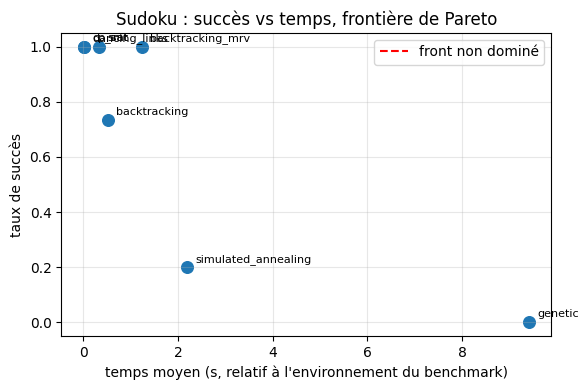

In [9]:
sud_p = profiles["sudoku"].set_index("paradigm")
front = non_dominated(profiles["sudoku"], [("success_rate", "max"), ("mean_time", "min")])
plt.figure(figsize=(6, 4))
plt.scatter(profiles["sudoku"]["mean_time"], profiles["sudoku"]["success_rate"], s=70)
for name, row in profiles["sudoku"].set_index("paradigm").iterrows():
    plt.annotate(name, (row["mean_time"], row["success_rate"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)
plt.plot(front["mean_time"], front["success_rate"], "r--", label="front non dominé")
plt.xlabel("temps moyen (s, relatif à l'environnement du benchmark)")
plt.ylabel("taux de succès")
plt.title("Sudoku : succès vs temps, frontière de Pareto")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Exercice 2 (stub) — Pareto à trois objectifs
Étendre la comparaison à **3 objectifs** (succès, temps, mémoire) et retourner le front en 3D. Le code ci-dessus ne gère que 2 objectifs ; généralisez-le.


In [10]:
# INDICE :
#  - la fonction `non_dominated` accepte DÉJÀ une liste arbitraire d'objectifs (obj_spec).
#  - il suffit d'y ajouter ("mean_mem", "min") comme troisième objectif.
#  - pensez à vérifier que les colonnes existent dans le profil (mean_mem est là).
def pareto_3d(df, use_memory=True):
    # Retourne le front de Pareto sur 3 objectifs : max succès, min temps, min mémoire.
    obj_spec = [("success_rate", "max"), ("mean_time", "min")]
    if use_memory:
        obj_spec.append(("mean_mem", "min"))   # ÉTAPE : ajouter la mémoire
    return non_dominated(df, obj_spec)  # TODO : implémenter la sélection (délégue à non_dominated)

# --- Test : front à 3 objectifs sur Sudoku ---
# f3 = pareto_3d(profiles["sudoku"])
# print(f3[["paradigm","success_rate","mean_time","mean_mem"]].round(3).to_string(index=False))
print("Exercice 2 (stub) — à compléter pour un front de Pareto à trois objectifs.")

Exercice 2 (stub) — à compléter pour un front de Pareto à trois objectifs.


## 6. Sélection sous préférences : le coût du choix

Le front de Pareto restreint les candidats, mais ne **décide pas** : il faut **arbitrer**. C'est le cœur du problème de **Rice** — à un ensemble d'instances et un choix d'objectifs, on associe l'algorithme qui **satisfait le mieux les préférences** du décideur.

Cette pondération est une version simplifiée de la décision multi-attribut de [DecInfer-04](../../../Probas/DecisionTheory/DecInfer/DecInfer-04-Multi-Attribute.ipynb) : modèle additif, poids explicites, normalisation et analyse de sensibilité. Elle suppose notamment que les critères sont suffisamment indépendants et **compensables** — hypothèses qu'un score numérique ne rend pas vraies par magie. [DecInfer-06](../../../Probas/DecisionTheory/DecInfer/DecInfer-06-Value-Information.ipynb) ajoute une autre question : caractériser une instance ou lancer un probe n'a de valeur que si le meilleur choix obtenu rembourse le **coût de cette information**.

On normalise chaque objectif *dans* son jeu (0 = pire, 1 = meilleur), puis on pondère selon 4 profils de préférence. Le **gagnant change** selon les poids : il n'existe pas de solveur universellement meilleur (écho du **No Free Lunch**).


In [11]:
def norm01(s, direction='max'):
    s = s.astype(float)
    lo, hi = s.min(), s.max()
    if hi == lo: return pd.Series(np.ones_like(s), index=s.index)
    return (s - lo) / (hi - lo) if direction == 'max' else (hi - s) / (hi - lo)

def weighted_ranking(pr, weights, quality_dir='max', use_quality=True):
    # weights : dict {success, speed, mem, quality} -> poids (somme 1).
    # Les 4 objectifs sont normalisés dans [0,1] avec 'mieux = plus haut'.
    # use_quality=False : qualité exclue (ex. Sudoku, où elle est une fitness partielle d'échec).
    paradigm = pr["paradigm"].to_numpy()
    score = np.zeros(len(paradigm))
    def accum(col, w, dirn):
        nonlocal score
        if w:
            score += w * norm01(pr[col], dirn).to_numpy()
    accum("success_rate", weights.get("success", 0), 'max')
    accum("rel_time", weights.get("speed", 0), 'max')
    accum("rel_mem", weights.get("mem", 0), 'max')
    if use_quality and "mean_quality" in pr.columns and not pr["mean_quality"].isna().all():
        accum("mean_quality", weights.get("quality", 0), quality_dir)
    order = np.argsort(-score)
    return pd.DataFrame({"paradigm": paradigm[order], "score": score[order]}).reset_index(drop=True)

# Spécification par jeu : direction de la qualité + pertinence comme objectif.
# Sudoku : qualité = fitness partielle d'échec -> pas un objectif de sélection.
game_spec = {
    "sudoku":       {"quality_dir": "max", "use_quality": False},
    "connect_four": {"quality_dir": "max", "use_quality": True},
    "wordle":       {"quality_dir": "min", "use_quality": True},
}

weight_sets = {
    "rapidité":  {"success": .2, "speed": .6, "mem": .1, "quality": .1},
    "mémoire":   {"success": .2, "speed": .1, "mem": .6, "quality": .1},
    "robustesse":{"success": .7, "speed": .1, "mem": .1, "quality": .1},
    "qualité":   {"success": .2, "speed": .1, "mem": .1, "quality": .6},
}

for g in games:
    spec = game_spec[g]
    pr = profiles[g]
    # Candidats viables : un solveur qui échoue sur 100 % des instances n'est pas
    # un candidat réel de sélection (il ne résout rien).
    viable = pr[pr["success_rate"] > 0] if "success_rate" in pr.columns else pr
    print(f"===== {g} : gagnant sous chaque profil de préférence (candidats viables) =====")
    for label, w in weight_sets.items():
        r = weighted_ranking(viable, w, spec["quality_dir"], use_quality=spec["use_quality"])
        top = r.iloc[0]
        extra = " | ".join(f"{i+1}e: {r.iloc[i]['paradigm']}" for i in range(1, min(3, len(r))))
        print(f"  {label:11s} -> {top['paradigm']:22s} (score {top['score']:.3f})" + (f" |  {extra}" if extra else ""))
    excluded = sorted(set(pr["paradigm"]) - set(viable["paradigm"]))
    if excluded:
        print(f"  [exclus, succès=0] : {', '.join(excluded)}")
    print()

===== sudoku : gagnant sous chaque profil de préférence (candidats viables) =====
  rapidité    -> dancing_links          (score 0.894) |  2e: cp_sat | 3e: backtracking_mrv
  mémoire     -> dancing_links          (score 0.861) |  2e: backtracking_mrv | 3e: backtracking
  robustesse  -> dancing_links          (score 0.894) |  2e: backtracking_mrv | 3e: cp_sat
  qualité     -> dancing_links          (score 0.394) |  2e: backtracking_mrv | 3e: cp_sat
  [exclus, succès=0] : genetic

===== connect_four : gagnant sous chaque profil de préférence (candidats viables) =====
  rapidité    -> alpha_beta             (score 0.800) |  2e: minimax
  mémoire     -> minimax                (score 0.900) |  2e: alpha_beta
  robustesse  -> minimax                (score 0.900) |  2e: alpha_beta
  qualité     -> minimax                (score 0.900) |  2e: alpha_beta
  [exclus, succès=0] : baseline, mcts

===== wordle : gagnant sous chaque profil de préférence (candidats viables) =====
  rapidité    -> bayes

**Résultat clé.** Aucun paradigme n'est le « meilleur » en toutes circonstances :
- **Sudoku** — **Dancing Links** gagne sous **tous** les profils (succès 100 %, le plus rapide, mémoire légère) : sur ce problème, le front se réduit à un point et la dominance est nette. La « qualité » étant exclue (fitness partielle d'échec, §4), le profil « qualité » retombe sur le même gagnant. `genetic` est **écarté** (succès 0).
- **Puissance 4** — un **vrai arbitrage** apparaît : `minimax` gagne mémoire/robustesse/qualité (qualité la plus haute), `alpha_beta` gagne **rapidité** (plus rapide à succès comparable). `baseline` et `MCTS` sont **écartés** (succès 0). C'est ici que le coût du choix est tangible.
- **Wordle** — `bayesian_elimination` gagne rapidité/mémoire/robustesse ; `entropy` gagne **qualité** (le moins de coups). Le **CSP** est dominé sur ce couple. Le basculement vitesse↔qualité est le plus lisible.

**Deux précautions de méthode.** (1) On **écarte les candidats non viables** (succès 0) : sans ce filtre, un objectif mal choisi (sur-pondérer la vitesse) ferait gagner un solveur qui **ne résout rien** — le coût d'une négligence modélée. (2) On **exclut la qualité** pour Sudoku : sa colonne `solution_quality` est une fitness partielle d'échec, pas une qualité de solution (§4).

**Le coût du choix** est dès lors explicite : la « meilleure solution » dépend de *qui* décide et de *ce qu'il privilégie* — et la décision de **quels objectifs** inclure est elle-même un choix de modélisation (cœur du problème de **Rice**).

Une petite analyse de sensibilité rend ce point mesurable : sur Wordle, faisons varier continûment le poids de la qualité, les autres poids se partageant le reste dans des proportions fixes.


In [12]:
wordle_viable = profiles["wordle"].query("success_rate > 0")
rows = []
for quality_weight in np.linspace(0, 1, 21):
    rest = 1 - quality_weight
    weights = {"success": .5 * rest, "speed": .3 * rest, "mem": .2 * rest,
               "quality": quality_weight}
    ranking = weighted_ranking(wordle_viable, weights, quality_dir="min", use_quality=True)
    rows.append({"poids_qualite": quality_weight, "gagnant": ranking.iloc[0]["paradigm"]})
sensitivity = pd.DataFrame(rows)
print("Wordle — gagnant selon le poids accordé au nombre de coups :")
print(sensitivity.groupby("gagnant")["poids_qualite"].agg(["min", "max", "count"]).to_string())
print("\nPoints de bascule :")
print(sensitivity.loc[sensitivity["gagnant"].ne(sensitivity["gagnant"].shift())].to_string(index=False))

Wordle — gagnant selon le poids accordé au nombre de coups :
                      min   max  count
gagnant                               
bayesian_elimination  0.0  0.25      6
entropy               0.3  1.00     15

Points de bascule :
 poids_qualite              gagnant
           0.0 bayesian_elimination
           0.3              entropy


**Interprétation.** Le point de bascule n'est pas une propriété naturelle de Wordle : il dépend de la normalisation et des proportions retenues entre succès, vitesse et mémoire. C'est précisément pourquoi [DecInfer-04](../../../Probas/DecisionTheory/DecInfer/DecInfer-04-Multi-Attribute.ipynb) enseigne l'élicitation et la sensibilité des poids, et pourquoi le score doit rester une décision documentée plutôt qu'un podium.

### Exercice 3 (stub) — sélecteur leave-one-family-out
Tester la **robustesse** du choix : si on **retire** une famille du banc, le gagnant change-t-il ? Un sélecteur qui dépend d'un seul « outsider » est fragile.


In [13]:
# INDICE :
#  - `profiles[g]` est un DataFrame avec une ligne par paradigme.
#  - retirer une famille = exclure ses lignes puis relancer `weighted_ranking`.
#  - comparer le gagnant avec/sans la famille retirée, pour chaque poids.
def leave_one_family_out(pr, weights, quality_dir='max', family=None):
    # Retire `family` (ou toutes tour à tour si None) et retourne le gagnant du ranking.
    cand = pr
    if family is not None:
        cand = pr[pr["paradigm"] != family]   # ÉTAPE : exclure la famille
    r = weighted_ranking(cand, weights, quality_dir)
    return r.iloc[0]["paradigm"]  # TODO : implémenter (retourne le gagnant sans `family`)

# --- Test : le gagnant de "rapidité" sur Wordle change-t-il si on retire l'entropie ? ---
# alt = leave_one_family_out(profiles["wordle"], weight_sets["rapidité"], "min", family="entropy")
# print("Gagnant 'rapidité' sans entropy :", alt)
print("Exercice 3 (stub) — à compléter pour un sélecteur leave-one-family-out.")

Exercice 3 (stub) — à compléter pour un sélecteur leave-one-family-out.


## 6 bis. Mesurer, choisir, certifier : trois questions différentes

Le benchmark empirique répond à **« que s'est-il passé sur ces instances, avec cette machine et ce protocole ? »**. Il ne prouve ni la correction générale d'un solveur ni son optimalité. CoursIA permet de situer précisément ces niveaux :

| Niveau | Question | Pont CoursIA | Ce que le pont établit — et n'établit pas |
|---|---|---|---|
| **Performance empirique** | Quel solveur réussit, à quel coût observé ? | [Sudoku-18](../../../Sudoku/Sudoku-18-Comparison-Python.ipynb), [Sudoku-18b](../../../Sudoku/Sudoku-18b-Statistical-Comparison-Python.ipynb) | Comparaison et incertitude sur un protocole ; aucune preuve universelle. |
| **Correction / invariants** | Une étape de propagation conserve-t-elle les solutions ? | [Sudoku-19-Lean-Propagation](../../../Sudoku/Sudoku-19-Lean-Propagation.ipynb) | Formalise des invariants de propagation ; **ne vérifie pas** les implémentations de Théodore. |
| **Optimalité conditionnelle** | Sous quelles hypothèses une stratégie est-elle optimale ? | [Search-03e-AStar-Optimality](../../Part1-Foundations/Search-03e-AStar-Optimality.ipynb) | Prouve une optimalité sous hypothèses (heuristique admissible, modèle formel) ; ne transforme pas un chrono en théorème. |
| **Valeur d'un jeu adverse** | Comment relier valeur minimax et stratégie ? | [GameTheory-05b-Lean-Minimax](../../../GameTheory/GameTheory-05b-Lean-Minimax.ipynb) | Donne les fondations formelles de minimax ; ne certifie ni le moteur Puissance 4 ni ses performances. |
| **Décision** | Comment arbitrer entre attributs et coût d'information ? | [DecInfer-02-Lean-ExpectedUtility](../../../Probas/DecisionTheory/DecInfer/DecInfer-02-Lean-ExpectedUtility.ipynb), [DecInfer-06](../../../Probas/DecisionTheory/DecInfer/DecInfer-06-Value-Information.ipynb) | Formalise le langage du choix ; les poids et distributions restent à justifier empiriquement. |

Cette séparation évite deux confusions symétriques : **un solveur rapide n'est pas, pour cette raison, prouvé correct** ; **un algorithme prouvé correct ou optimal sous hypothèses n'est pas, pour cette raison, le plus rapide ici**. Le prolongement naturel serait un pipeline où une preuve borne l'espace des candidats admissibles, puis où la sélection empirique arbitre entre les candidats certifiés.


## 7. Limites honnêtes

Un hommage ne maquille pas les faiblesses : il les expose, car elles font partie de l'apport.

1. **Collecte Unix uniquement.** Le paquet `benchmark` importe `resource` et utilise `SIGALRM` pour les timeouts → la collecte des résultats **échoue sous Windows natif** (les 20 tests du dépôt passent sous WSL/Linux). Les CSV livrés ont donc été produits sous **Unix**. C'est une **limite de portabilité** assumée, pas un défaut caché.
2. **Une seule observation historique par solveur × instance.** Les trois CSV étudiants permettent d'étudier la variabilité **entre instances**, pas le bruit d'exécution à instance fixée. Les IC bootstrap du §2 bis-A ré-échantillonnent les instances ; ils ne doivent pas être lus comme des répétitions runtime.
3. **Répétition fraîche volontairement petite.** L'extension CoursIA Wordle porte sur 3 instances × 5 graines × 3 solveurs. Elle satisfait l'objectif de rendre la dispersion visible, mais trois mots ne suffisent pas pour une conclusion confirmatoire. Le cache entropique a été vidé avant chaque répétition afin de conserver un état froid comparable ; un protocole warm-cache répondrait à une autre question.
4. **Effectifs inégaux sur Puissance 4.** Les familles couvrent 6 à 10 instances ; les quatre ne partagent que **6 `instance_id`**. Les taux et moyennes sont donc fragiles, et une comparaison appariée globale devrait se restreindre à ce sous-panel.
5. **Métriques hétérogènes.** `nodes_explored`, `solution_quality` et même `time_seconds` ne comparent pas la même chose d'une famille à l'autre (§3, §4). Les profils sont donc **intra-jeu**.
6. **Mémoire `ru_maxrss`.** Le pic mémoire est le `ru_maxrss` du **processus**, pas une allocation fine ; le GA/recuit allouent beaucoup et gonflent ce chiffre. À interpréter avec prudence.
7. **Stochasticité partiellement caractérisée.** Le multi-seed Wordle montre que l'entropie est déterministe à instance fixée, tandis que l'élimination bayésienne et le CSP varient. GA, recuit et MCTS restent décrits par une seule observation historique par instance : leur variance inter-seed n'est pas estimée ici.
8. **Sous-ensemble de familles.** Le README étudiant précise : **6 paradigmes Sudoku** sur **17 possibles** (choix représentatif de chaque famille — recherche exacte, CSP/SAT, métaheuristique) ; **Choco** et les solveurs **neuronaux/LLM** ne sont pas implémentés (mentionnés en perspective). Le benchmark compare donc un **échantillon**, pas l'espace complet.
9. **Pas de généralisation universelle ni de certification implicite.** Les succès/échecs sont spécifiques à ces terrains, ces instances et ce protocole. Le No Free Lunch interdit d'en déduire un dominateur universel ; les ponts Lean du §6 bis éclairent des propriétés formelles distinctes, sans vérifier le code étudiant.

Ces limites **renforcent** le propos : la comparabilité se **construit** (provenance, schéma, normalisation, Pareto) — elle n'est jamais donnée.


## 8. Traçabilité : de la question étudiante au cadre pédagogique

Le tableau ci-dessous relie **la question que se posait l'étudiant**, **l'appareil** qu'il a construit, **le résultat que ce notebook reproduit**, et **l'extension pédagogique** que CoursIA en tire.


In [14]:
trace = pd.DataFrame({
    "Question étudiante": [
        "Quelle famille est la plus rapide sur Sudoku ?",
        "Les métriques sont-elles comparables entre paradigmes ?",
        "Un classement unique est-il légitime ?",
        "Quel solveur pour Puissance 4 en recherche adverse ?",
        "Wordle : information vs contraintes, qui gagne ?",
        "Que peut-on conclure au-delà d'une moyenne ?",
        "Mesurer une performance revient-il à prouver un algorithme ?",
    ],
    "Appareil étudiant": [
        "Protocole commun (instances, timeouts 120 s, parallélisation)",
        "Colonnes uniformes `time`/`mem`/`nodes` par solveur",
        "Tables de résultats `results/*.csv` + notebook d'analyse",
        "minimax / alpha-beta / MCTS / baseline, tournoi round-robin",
        "élimination bayésienne / entropie / CSP sur listes de mots",
        "`instance_id` partagé dans les CSV historiques",
        "Solveurs exécutables et mesures empiriques",
    ],
    "Résultat reproduit ici": [
        "Dancing Links et CP-SAT dominent ; métaheuristiques échouent",
        "`nodes_explored` non commensurable (CP-SAT≈55, GA≈400k)",
        "Front de Pareto + gagnant dépendant des poids (§5-6)",
        "alpha-beta ~ minimax ~67 % ; MCTS/baseline 0 %",
        "historique + 45 runs frais sur 3 instances Wordle",
        "IC inter-instance + bootstrap hiérarchique (§2 bis)",
        "Aucune certification déduite des chronos (§6 bis)",
    ],
    "Extension pédagogique": [
        "La sélection d'algorithmes (Rice) a un coût empirique",
        "Non-commensurabilité = cas d'école des attributs d'instance",
        "Un podium unique efface les compromis (Pareto)",
        "Choix d'objectifs = décision de modélisation, pas un fait",
        "Dispersion, cache froid et stochasticité deviennent observables",
        "Une observation, une répétition et une population ne se confondent pas",
        "Performance, correction et optimalité restent trois niveaux distincts",
    ],
})
print(trace.to_string(index=False))

                                          Question étudiante                                             Appareil étudiant                                       Résultat reproduit ici                                                  Extension pédagogique
              Quelle famille est la plus rapide sur Sudoku ? Protocole commun (instances, timeouts 120 s, parallélisation) Dancing Links et CP-SAT dominent ; métaheuristiques échouent                  La sélection d'algorithmes (Rice) a un coût empirique
     Les métriques sont-elles comparables entre paradigmes ?           Colonnes uniformes `time`/`mem`/`nodes` par solveur      `nodes_explored` non commensurable (CP-SAT≈55, GA≈400k)            Non-commensurabilité = cas d'école des attributs d'instance
                      Un classement unique est-il légitime ?      Tables de résultats `results/*.csv` + notebook d'analyse         Front de Pareto + gagnant dépendant des poids (§5-6)                         Un podium unique efface les

## Conclusion

Le benchmark de **Théodore Deguest** est plus qu'un comparatif : c'est un **appareil de mesure de la sélection d'algorithmes**. Quatre leçons s'en dégagent quand on l'associe au cadre de **Rice** et au **No Free Lunch** :

1. **La comparabilité se construit.** Provenance vérifiée, schéma validé, normalisation intra-jeu : rien n'est « naturellement » comparable entre un nœud de Dancing Links, une décision CP-SAT et une simulation MCTS.
2. **Un classement unique est un choix caché.** La frontière de Pareto révèle des compromis qu'un score agrégé écrase ; le gagnant dépend des **préférences** du décideur (voir §6).
3. **L'incertitude doit nommer ce qu'elle ré-échantillonne.** Les CSV historiques quantifient la diversité des instances ; les 45 runs Wordle ajoutent une petite fenêtre sur la dispersion inter-seed, avec cache froid contrôlé. Aucun des deux protocoles ne prétend remplacer une campagne confirmatoire.
4. **Mesurer, choisir et certifier sont trois gestes.** Les résultats empiriques orientent un choix ; les notebooks Lean explicitent des garanties sous hypothèses distinctes ; aucun chrono ne certifie le code de Théodore et aucune preuve abstraite ne garantit le meilleur temps observé.

**À retenir de l'hommage :** le geste étudiant (faire courir ensemble des paradigmes hétérogènes sur un protocole honnête) est conservé, attribué, reproduit et **élevé** en cas d'application du problème de sélection d'algorithmes. Il ne s'agit pas de « mentionner » le travail : il s'agit de le **faire travailler** dans un cadre plus grand, sans lui attribuer les extensions statistiques ni les preuves formelles de CoursIA.

## Sources

- **Travail distillé** : Théodore Deguest, *« Benchmark cross-paradigme de solveurs de jeux »* — sujet L4, cours Intelligence Symbolique, EPITA SCIA. PR [#42](https://github.com/jsboigeEpita/2026-Epita-Intelligence-Symbolique/pull/42), projet [L4-Benchmark-Cross-Paradigm](https://github.com/jsboigeEpita/2026-Epita-Intelligence-Symbolique/tree/main/L4-Benchmark-Cross-Paradigm). Dépôt source sous **licence MIT** (copyright 2026, *The 2026-Epita-Intelligence-Symbolique contributors*). Données : `results/{sudoku,connect_four,wordle}_results.csv`.
- **Cadre théorique** :
  - **Rice, J. R. (1976)** — *« The Algorithm Selection Problem »*, Advances in Computers 15, pp. 65-118.
  - **Wolpert, D. H. & Macready, W. G. (1997)** — *« No Free Lunch Theorems for Optimization »*, IEEE Trans. on Evolutionary Computation 1(1), pp. 67-82.
- **Arc sélection et représentation** :
  - [MGS-15-LandscapeAnalysis](../../Part4-Metaheuristics/MGS-15-LandscapeAnalysis.ipynb) → [MGS-16-AlgorithmSelection](../../Part4-Metaheuristics/MGS-16-AlgorithmSelection.ipynb) → [MGS-21-Representation-vs-Algorithme](../../Part4-Metaheuristics/MGS-21-Representation-vs-Algorithme.ipynb).
  - [App-10-Portfolio](App-10-Portfolio.ipynb), [App-18-HyperparameterTuning](App-18-HyperparameterTuning.ipynb) et [MGS-17-ParameterControl](../../Part4-Metaheuristics/MGS-17-ParameterControl.ipynb) — portfolio, configuration et contrôle ne sont pas la même question.
- **Arc expérimental et décision** :
  - [Sudoku-18-Comparison-Python](../../../Sudoku/Sudoku-18-Comparison-Python.ipynb) / [Sudoku-18b-Statistical-Comparison-Python](../../../Sudoku/Sudoku-18b-Statistical-Comparison-Python.ipynb) — comparaison, répétitions et incertitude.
  - [DecInfer-04-Multi-Attribute](../../../Probas/DecisionTheory/DecInfer/DecInfer-04-Multi-Attribute.ipynb) / [DecInfer-06-Value-Information](../../../Probas/DecisionTheory/DecInfer/DecInfer-06-Value-Information.ipynb) — score multi-attribut et coût d'information.
- **Terrains applicatifs** :
  - [App-20-SudokuBenchmark-Python](../CSP/App-20-SudokuBenchmark-Python.ipynb), [App-14b-ConnectFour](../Search/App-14b-ConnectFour.ipynb), [App-14-ConnectFour-Adversarial](../Search/App-14-ConnectFour-Adversarial.ipynb), [App-7-Wordle](../CSP/App-7-Wordle.ipynb).
- **Ponts formels, sans certification du code étudiant** :
  - [Sudoku-19-Lean-Propagation](../../../Sudoku/Sudoku-19-Lean-Propagation.ipynb), [Search-03e-AStar-Optimality](../../Part1-Foundations/Search-03e-AStar-Optimality.ipynb), [GameTheory-05b-Lean-Minimax](../../../GameTheory/GameTheory-05b-Lean-Minimax.ipynb), [DecInfer-02-Lean-ExpectedUtility](../../../Probas/DecisionTheory/DecInfer/DecInfer-02-Lean-ExpectedUtility.ipynb).
